In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import sys

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import pandas as pd
import statsmodels.api as sm

import seaborn as sns

path = '/media/fkaiser/'

sys.path.append('../power_system_split/')
import utils,visualisation

# Evaluate component cluster for CO$_2$ levels together

## Setup and load graph

In [35]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'
cluster_results_path = '/media/jkruse/Projects/system_splits/power-system-split/results/'

criterion = 'nodes' # or 'load'
snet_index = 0 # only AC grid of CE
co2l_list = co2ls = np.arange(0.0,0.99,0.05)

n_subset_solutions = -1 # number of random sampled time steps from each co2 level simulation, -1 means all

In [36]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
G = utils.build_networkx_graph(network, snet_index = snet_index)


/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/media/jkruse/Projects/system_splits/power-system-split/venv/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [37]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)

if n_subset_solutions==-1:
    n_time_stamps = network.snapshots.size
else:
    n_time_stamps = n_subset_solutions

number_of_simulations = n_initial_failures*n_time_stamps

## Load clustering results

In [97]:
indicator_vectors = np.load(cluster_results_path + 'indicator_vectors_all_co2level_{}_based.npy'.format(criterion))
component_props = pd.read_hdf(cluster_results_path + 'split_component_properties_all_co2level_{}_based.h5'.format(criterion))
cluster_result_name = 'cluster_label_agg_mdist{}'.format(19/ len(G))

print('Number of cluster (including noise-cluster in dbscan):', component_props.loc[:,cluster_result_name].unique().size)

Number of cluster (including noise in dbscan): 58


## Add component and cluster properties 

In [99]:
# Add component properties
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy
component_props.loc[:, 'number_of_nodes'] = indicator_vectors.sum(1)

# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby([cluster_result_name,'co2l']).size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby([cluster_result_name,'co2l'])['number_of_nodes'].mean()

# Count infinity rocofs and then set them no nan in component properties
cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby([cluster_result_name,'co2l']).apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby([cluster_result_name,'co2l']).apply(lambda x: np.isneginf(x.rocof).sum())
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()


# Calculate rocof statistics for each cluster given a certain co2 level
cluster_props.loc[:,'median_rocof'] = component_props.groupby([cluster_result_name,'co2l'])['rocof'].median()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].mean()
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].median().abs()
cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].mean().abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby([cluster_result_name,'co2l'])['rocof'].quantile(0.95).abs() #max()

# convert rocof to absolute rocof and save sign
component_props.loc[:,'rocof_positive'] = component_props.loc[:,'rocof']>0
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].abs()

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()

counts  likelihood  mean_number_of_nodes  \
cluster_label_agg_mdist0.03125 co2l                                             
0                              0.00     305    0.000109             17.698361   
                               0.05     190    0.000068             16.821053   
                               0.10     100    0.000036             18.320000   
                               0.15     116    0.000042             17.327586   
                               0.20     174    0.000062             17.942529   

                                     number_pos_inf_rocofs  \
cluster_label_agg_mdist0.03125 co2l                          
0                              0.00                     26   
                               0.05                     12   
                               0.10                      5   
                               0.15                      5   
                               0.20                     11   

                                     number_neg_inf_rocofs  median_rocof  \
cluster_label_agg_mdist0.03125 co2l                                        
0                              0.00                      0    113.775083   
                               0.05                      0     19.745343   
                               0.10                      0    123.731868   
                               0.15                      0    103.567421   
                               0.20                      0    201.767596   

                                     median_pos_rocof  mean_pos_rocof  \
cluster_label_agg_mdist0.03125 co2l                                     
0                              0.00        115.331003    13993.083234   
                               0.05         24.810398    14465.584809   
                               0.10        149.818653    19194.069069   
                               0.15        143.597499    18377.128424   
                               0.20        228.536278    19984.257803   

                                     min_pos_rocof  max_pos_rocof  \
cluster_label_agg_mdist0.03125 co2l                                 
0                              0.00       9.557794   70305.607108   
                               0.05       2.198293   65178.082364   
                               0.10      13.066339   69985.295644   
                               0.15      13.423634   68715.264876   
                               0.20       6.310289   67753.869024   

                                     median_neg_rocof  mean_neg_rocof  \
cluster_label_agg_mdist0.03125 co2l                                     
0                              0.00          8.678309        9.405060   
                               0.05         19.992359     2984.417951   
                               0.10          8.964111       11.372646   
                               0.15          1.987945        2.664562   
                               0.20          5.825001        5.752750   

                                     max_neg_rocof  min_neg_rocof  
cluster_label_agg_mdist0.03125 co2l                                
0                              0.00      12.273695       7.553875  
                               0.05   23705.839679      14.134886  
                               0.10      23.415406       2.803243  
                               0.15       4.513635       1.762754  
                               0.20       7.484744       3.533374

## Select a few cluster for analysis

In [105]:
# Only select cluster if there is at least one co2l with P(cluster | co2l) significantly larger than p (alpha=0.05)
# (i.e. we omit very unlikely clusters)
p= 0.00001
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print('Rejected if not more than', int(max_counts), 'hits in all', number_of_simulations, 'simulations')

#selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
#n_selected_cluster = selected_cluster.get_level_values(cluster_result_name).unique().size

selected_cluster_mask = cluster_props.groupby(cluster_result_name).apply(lambda x: (x.counts>=max_counts).any())
selected_cluster = selected_cluster_mask[selected_cluster_mask].index
n_selected_cluster = selected_cluster.size

print('Labels of selected cluster:', selected_cluster)
print('Number of selected cluster:', n_selected_cluster)

Rejected if not more than 38 hits in all 2791520 simulations
Labels of selected cluster: Int64Index([0, 1, 2, 3, 4, 6, 8, 10, 16, 21, 24, 26], dtype='int64', name='cluster_label_agg_mdist0.03125')
Number of selected cluster: 12


## Plot cluster on map

<AxesSubplot:xlabel='cluster_label_agg_mdist0.03125'>

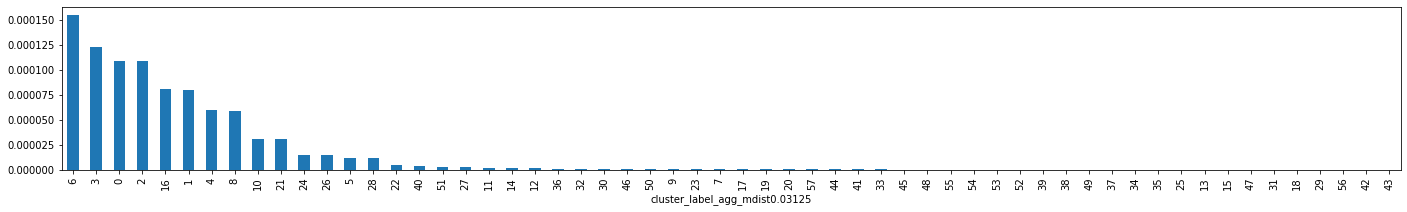

In [101]:
cluster_props.groupby(cluster_result_name).apply(lambda x: x.likelihood.max()).sort_values().iloc[::-1].plot.bar(figsize=(24,3))

# check how fast cluster probabilities decrease and for how much cases the selected ones account for

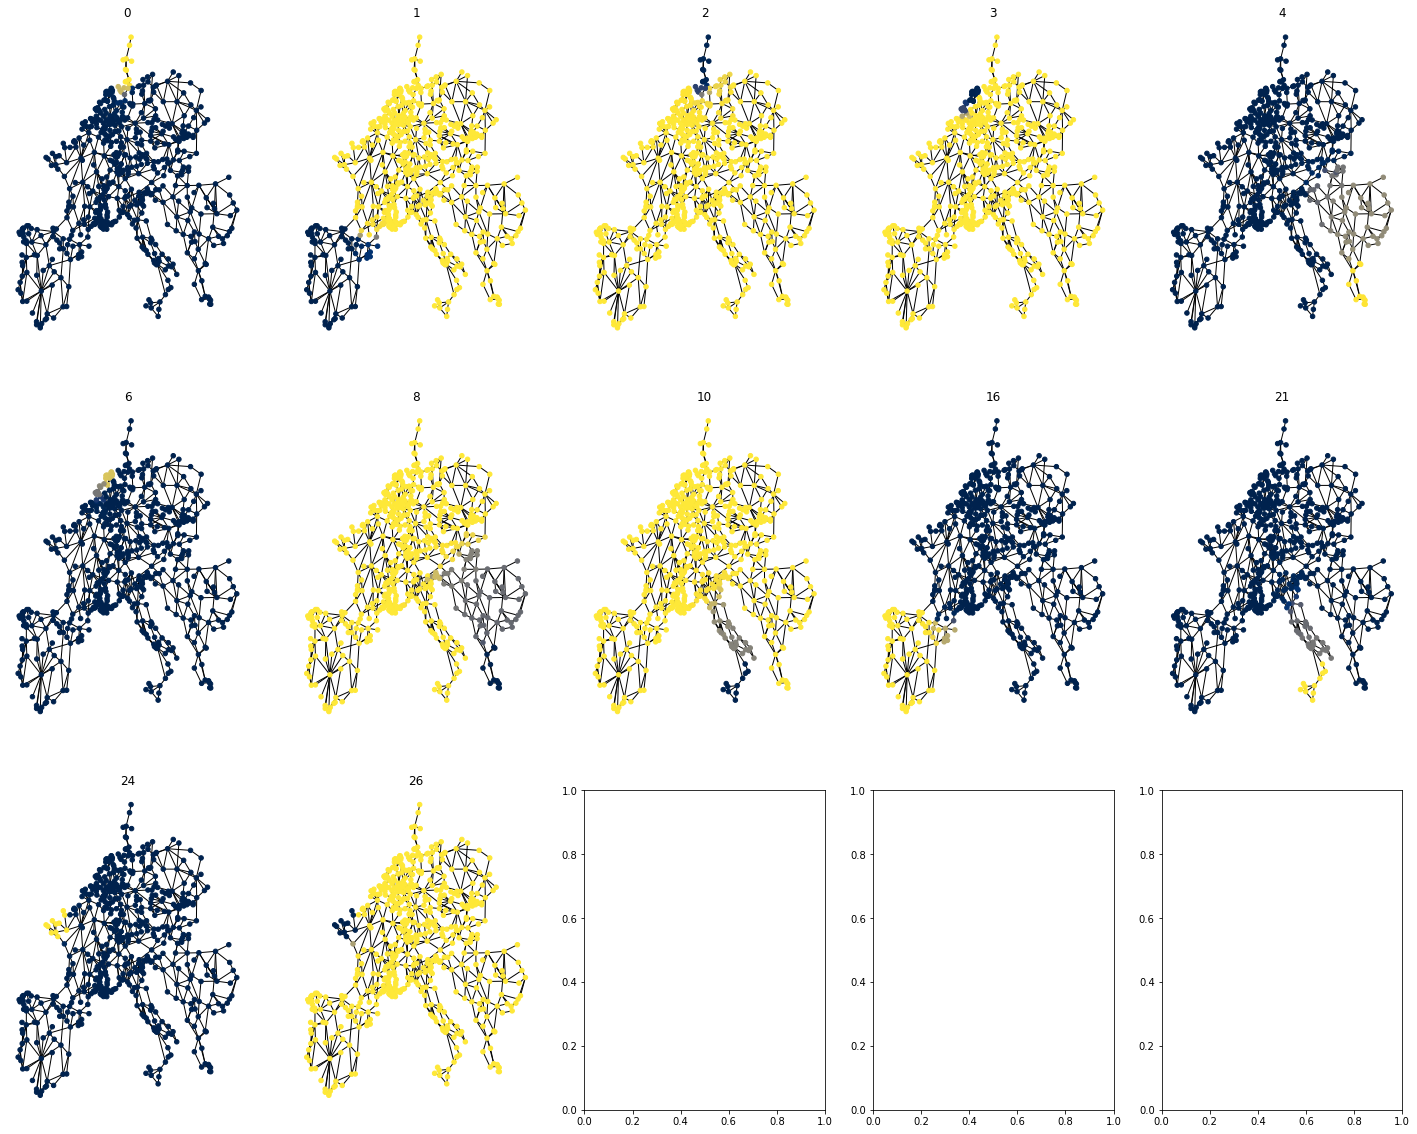

In [106]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 5 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize=(25,20))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.loc[:, cluster_result_name].isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.loc[:, cluster_result_name].isin(selected_cluster)].loc[:,cluster_result_name]

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     None,
                                     G)

## Infinite Rocofs

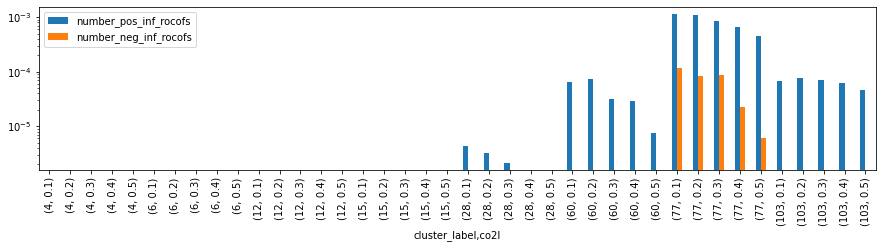

In [15]:
# Display number of infinite rocofs
cluster_props.loc[selected_cluster,['number_pos_inf_rocofs', 'number_neg_inf_rocofs']].div(number_of_simulations).plot.bar(figsize=(15,3))
plt.yscale('log')

## Dependence on CO$_2$ level

In [16]:
#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,[cluster_result_name, 'co2l']]).isin(selected_cluster)
#selected_components = component_props[selected_components_mask]

selected_components = component_props[component_props.cluster_label.isin(selected_cluster)]

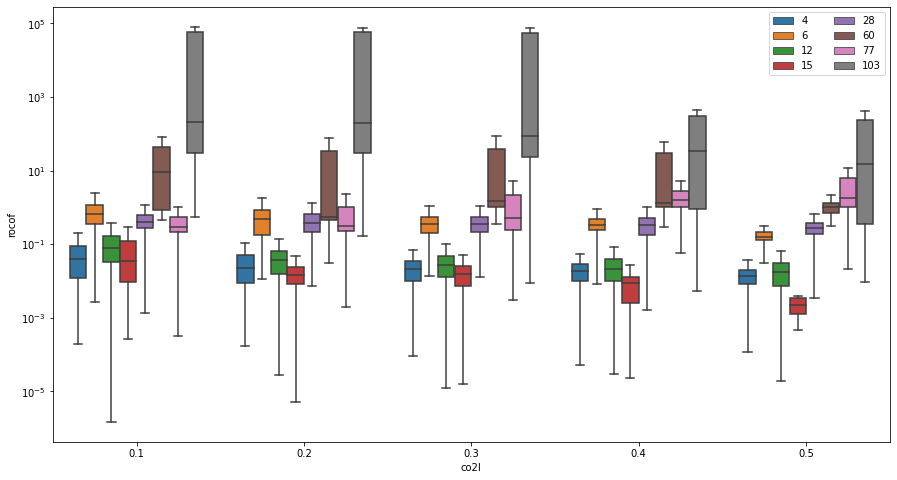

In [17]:
plt.figure(figsize=(15,8))
sns.boxplot(data=selected_components[selected_components.rocof_positive], x='co2l', y='rocof', hue=cluster_result_name, showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log')

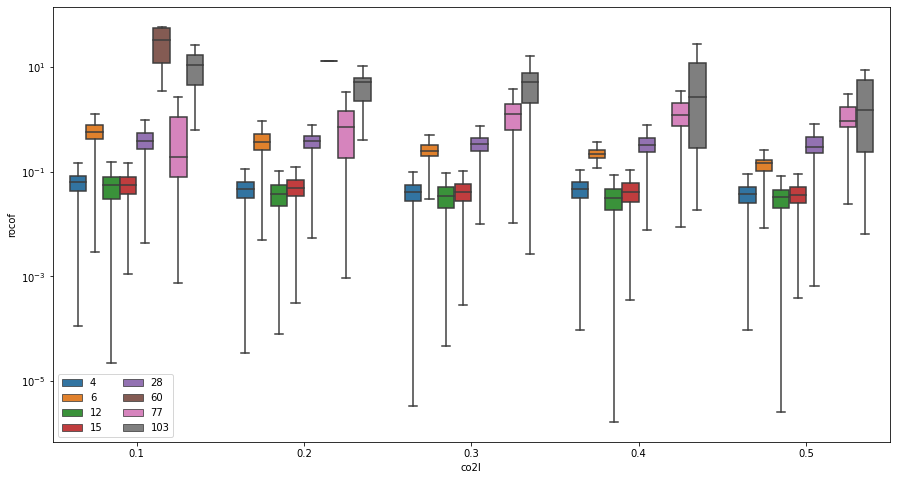

In [18]:
plt.figure(figsize=(15,8))
sns.boxplot(data=selected_components[~selected_components.rocof_positive], x='co2l', y='rocof', hue='cluster_label', showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log')

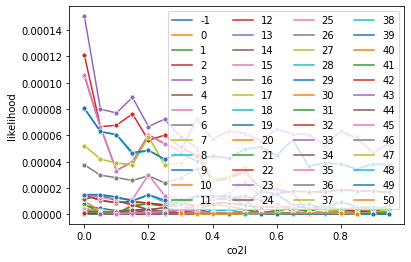

In [81]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='likelihood', hue=cluster_result_name, marker='.', ms=10, palette='tab10')
#plt.yscale('log')
plt.legend(ncol=4)

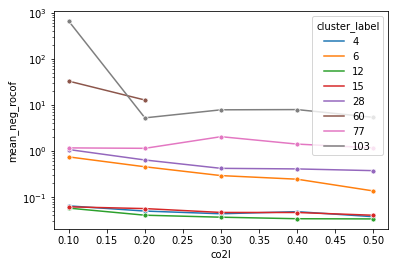

In [20]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='mean_neg_rocof', hue='cluster_label', marker='.', ms=10, palette='tab10')
plt.yscale('log')

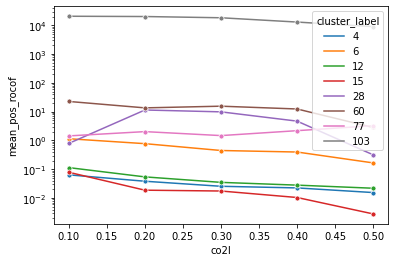

In [193]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='mean_pos_rocof', hue=cluster_result_name, marker='.', ms=10, palette='tab10')
plt.yscale('log')

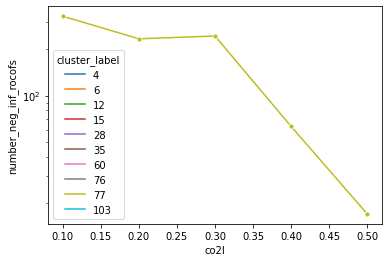

In [152]:
sns.lineplot(data=cluster_props.loc[selected_cluster].reset_index() , x='co2l', y='number_neg_inf_rocofs', hue='cluster_label', marker='.', ms=10, palette='tab10')
plt.yscale('log')

<AxesSubplot:xlabel='co2l', ylabel='rocof'>

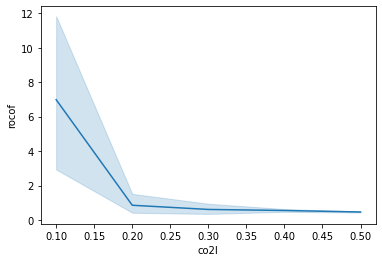

In [186]:
sns.lineplot(data=component_props[~component_props.rocof_positive] , x='co2l', y='rocof')

<AxesSubplot:xlabel='co2l', ylabel='rocof'>

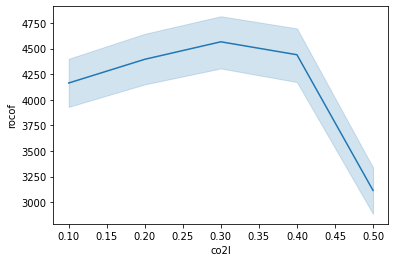

In [26]:
sns.lineplot(data=component_props[component_props.rocof_positive] , x='co2l', y='rocof')

In [30]:
component_props

,co2l,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation,cluster_label,rocof,number_of_nodes,rocof_positive
0,0.1,01_05_2013_00,3.0,4335.550000,-4372.831386,4146.846079,156,1.008599,51.0,False
1,0.1,01_05_2013_00,3.0,81110.607706,576.657255,34634.384485,59,0.007110,556.0,True
2,0.1,01_05_2013_00,15.0,85322.225436,-11276.023084,38370.441395,64,0.132158,597.0,False
3,0.1,01_05_2013_00,15.0,240.000000,7442.431957,434.992823,82,31.010133,11.0,True
4,0.1,01_05_2013_00,35.0,83678.225436,731.040911,34178.772298,112,0.008736,570.0,True
...,...,...,...,...,...,...,...,...,...,...
187164,0.5,31_12_2013_21,28.0,0.000000,7902.670353,434.989692,82,NaN,11.0,False
187165,0.5,31_12_2013_21,31.0,145341.760303,-7819.297952,45733.910734,4,0.053799,587.0,False
187166,0.5,31_12_2013_21,31.0,0.000000,4242.532132,3570.940202,77,NaN,21.0,False
187167,0.5,31_12_2013_21,45.0,145144.750303,-10501.904624,48252.952818,15,0.072355,590.0,False


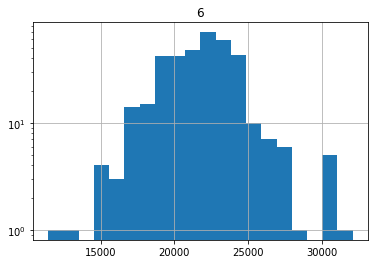

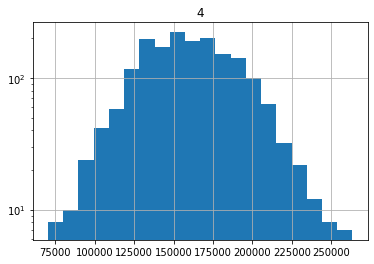

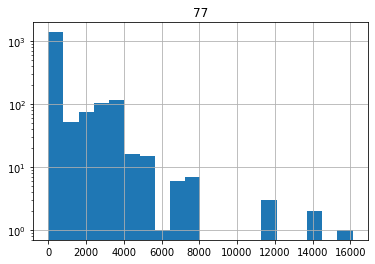

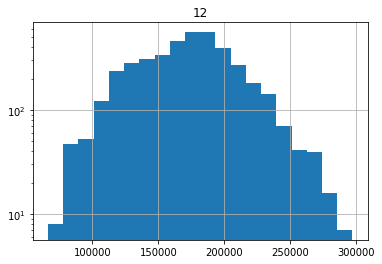

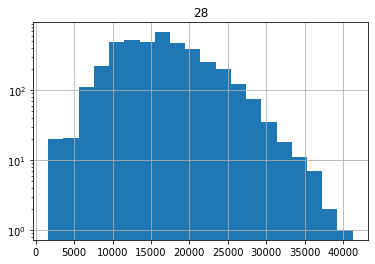

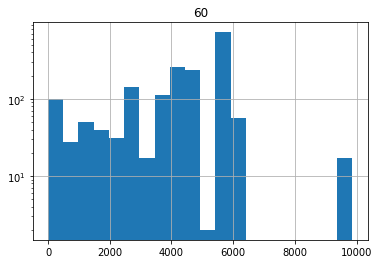

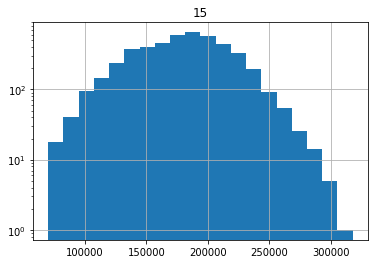

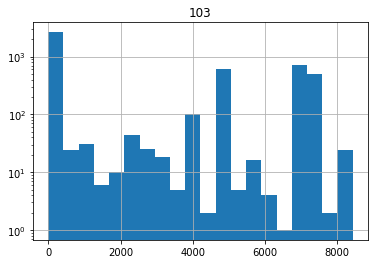

In [34]:
for label in selected_cluster_labels.unique():
    plt.figure()
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.5)].inertia_proxy.hist(log=True, bins=20)
    plt.title(label)
    
# plot: für jeden cluster 2 co2l visualisieren und mit der gesamt verteilung (über die zeit) vergleichen